<a href="https://colab.research.google.com/github/Afanul29/UnhealthyTilapiaFish/blob/main/NileTilapiaHealthBlawi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *Artificial Intelligence-Based Health Classification of Nile Tilapia (Oreochromis niloticus) Using Digital Image Processing and Deep Learning: A Case Study in Blawi Village, Lamongan Regency*

In [1]:
!pip install -q kagglehub
!pip install -q tensorflow
!pip install -q opencv-python
!pip install -q seaborn
!pip install -q scikit-learn
import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import kagglehub

In [2]:
path = kagglehub.dataset_download(
    "engineeringubu/enhancing-disease-detection-in-nile-tilapia"
)
print("Dataset Path:")
print(path)

100%|██████████| 452M/452M [00:03<00:00, 146MB/s]

Extracting files...


Dataset Path:
/root/.cache/kagglehub/datasets/engineeringubu/enhancing-disease-detection-in-nile-tilapia/versions/5


In [3]:
dataset_root = os.path.join(
    path,"archive","Dataset")
print(dataset_root)

/root/.cache/kagglehub/datasets/engineeringubu/enhancing-disease-detection-in-nile-tilapia/versions/5/archive/Dataset


In [4]:
for root, dirs, files in os.walk(dataset_root):
    print(root)

/root/.cache/kagglehub/datasets/engineeringubu/enhancing-disease-detection-in-nile-tilapia/versions/5/archive/Dataset
/root/.cache/kagglehub/datasets/engineeringubu/enhancing-disease-detection-in-nile-tilapia/versions/5/archive/Dataset/NTD-1
/root/.cache/kagglehub/datasets/engineeringubu/enhancing-disease-detection-in-nile-tilapia/versions/5/archive/Dataset/NTD-1/5.Motile Aeromonad Septicemia (MAS)
/root/.cache/kagglehub/datasets/engineeringubu/enhancing-disease-detection-in-nile-tilapia/versions/5/archive/Dataset/NTD-1/4.Tilapia Lake virus (TiLV)
/root/.cache/kagglehub/datasets/engineeringubu/enhancing-disease-detection-in-nile-tilapia/versions/5/archive/Dataset/NTD-1/3.Columnaris Disease(Col)
/root/.cache/kagglehub/datasets/engineeringubu/enhancing-disease-detection-in-nile-tilapia/versions/5/archive/Dataset/NTD-1/6.Normal Nile Tilapia(NN)
/root/.cache/kagglehub/datasets/engineeringubu/enhancing-disease-detection-in-nile-tilapia/versions/5/archive/Dataset/NTD-1/2.Parasitic Diseases (

In [5]:
new_dataset = "/content/tilapia_dataset"
os.makedirs(
    new_dataset,
    exist_ok=True
)

In [6]:
classes = [
    "Healthy",
    "Streptococcosis",
    "Parasitic",
    "Columnaris",
    "MAS",
    "TiLV"
]
for cls in classes:
    os.makedirs(
        os.path.join(new_dataset, cls),
        exist_ok=True
    )

In [7]:
mapping = {

    "1.Streptococcosis":
        "Streptococcosis",
    "2.Parasitic":
        "Parasitic",
    "3.Columnaris":
        "Columnaris",
    "4.Tilapia":
        "TiLV",
    "5.Motile":
        "MAS",
    "6.Normal":
        "Healthy"
}

In [8]:
for ntd_folder in ["NTD-1", "NTD-2"]:
    ntd_path = os.path.join(
        dataset_root,
        ntd_folder
    )
    for disease_folder in os.listdir(ntd_path):

        disease_path = os.path.join(
            ntd_path,
            disease_folder
        )
        if not os.path.isdir(
            disease_path
        ):
            continue
        target_class = None
        for key in mapping:
            if disease_folder.startswith(key):
                target_class = mapping[key]
                break
        if target_class is None:
            continue
        for image_file in os.listdir(
            disease_path
        ):
            src = os.path.join(
                disease_path,
                image_file
            )
            dst = os.path.join(
                new_dataset,
                target_class,
                f"{ntd_folder}_{image_file}"
            )
            shutil.copy(
                src,
                dst
            )

print(
    "Dataset merged successfully."
)

Dataset merged successfully.


In [9]:
for cls in classes:
    count = len(
        os.listdir(
            os.path.join(
                new_dataset,
                cls
            )
        )
    )
    print(
        cls,
        count
    )

Healthy 511
Streptococcosis 449
Parasitic 532
Columnaris 481
MAS 561
TiLV 520


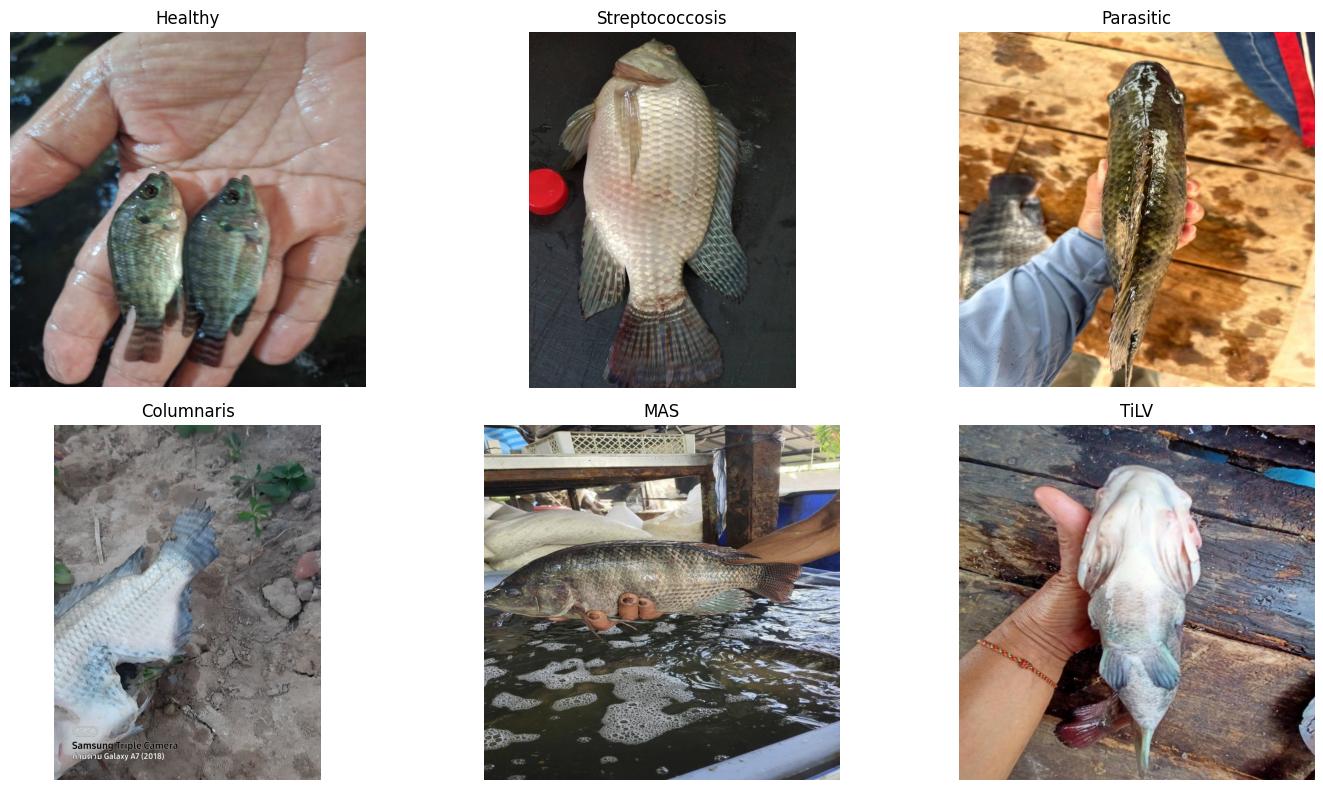

In [10]:
plt.figure(figsize=(15,8))
count = 1
for cls in classes:
    folder = os.path.join(
        new_dataset,
        cls
    )
    image_name = os.listdir(folder)[0]
    image_path = os.path.join(
        folder,
        image_name
    )
    img = cv2.imread(
        image_path
    )
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
    plt.subplot(
        2,
        3,
        count
    )
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    count += 1
plt.tight_layout()
plt.show()

In [11]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

In [12]:
train_generator = datagen.flow_from_directory(
    new_dataset,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

Found 2444 images belonging to 6 classes.


In [13]:
validation_generator = datagen.flow_from_directory(
    new_dataset,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 609 images belonging to 6 classes.


In [14]:
print(
    train_generator.class_indices
)

{'Columnaris': 0, 'Healthy': 1, 'MAS': 2, 'Parasitic': 3, 'Streptococcosis': 4, 'TiLV': 5}


In [15]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [17]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(
    256,
    activation="relu"
)(x)
x = Dropout(
    0.5
)(x)
outputs = Dense(
    train_generator.num_classes,
    activation="softmax"
)(x)
model = Model(
    inputs=base_model.input,
    outputs=outputs
)

In [18]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
history = model.fit(
    train_generator,
    validation_data=
        validation_generator,
    epochs=20
)

Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.6997 - loss: 0.8323 - val_accuracy: 0.3727 - val_loss: 7.4923
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.8891 - loss: 0.3506 - val_accuracy: 0.2808 - val_loss: 11.5914
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9059 - loss: 0.2618 - val_accuracy: 0.2151 - val_loss: 20.4318
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9419 - loss: 0.1675 - val_accuracy: 0.1839 - val_loss: 33.0084
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.9439 - loss: 0.1879 - val_accuracy: 0.3842 - val_loss: 12.1644
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9632 - loss: 0.1211 - val_accuracy: 0.4236 - val_loss: 10.3876
Epoch 7/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9673 - loss: 0.0891 - val_accuracy: 0.5172 - val_loss: 9.7291
Epoch 8/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9570 - loss: 0.1399 - val_accuracy: 0.341

In [20]:
loss, accuracy = model.evaluate(
    validation_generator
)
print(
    f"Accuracy: {accuracy*100:.2f}%"
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.4450 - loss: 20.1820
Accuracy: 44.50%


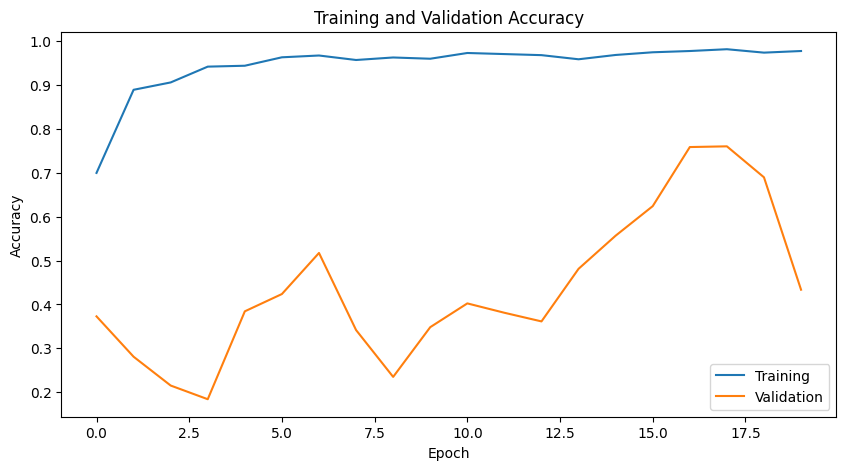

In [21]:
plt.figure(figsize=(10,5))
plt.plot(
    history.history["accuracy"]
)
plt.plot(
    history.history["val_accuracy"]
)
plt.title(
    "Training and Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend([
    "Training",
    "Validation"
])

plt.show()

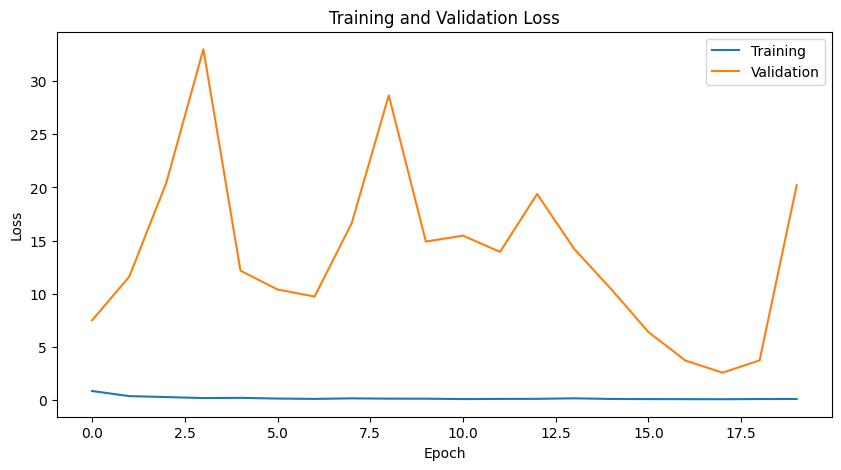

In [22]:
plt.figure(figsize=(10,5))
plt.plot(
    history.history["loss"]
)
plt.plot(
    history.history["val_loss"]
)
plt.title(
    "Training and Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend([
    "Training",
    "Validation"
])
plt.show()

In [23]:
predictions = model.predict(
    validation_generator
)
predicted_classes = np.argmax(
    predictions,
    axis=1
)
true_classes = validation_generator.classes
labels = list(
    validation_generator.class_indices.keys()
)
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=labels
    )
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step
                 precision    recall  f1-score   support

     Columnaris       1.00      0.27      0.43        96
        Healthy       1.00      0.18      0.30       102
            MAS       0.27      0.99      0.42       112
      Parasitic       1.00      0.28      0.44       106
Streptococcosis       0.28      0.08      0.12        89
           TiLV       0.86      0.79      0.82       104

       accuracy                           0.45       609
      macro avg       0.74      0.43      0.42       609
   weighted avg       0.74      0.45      0.43       609



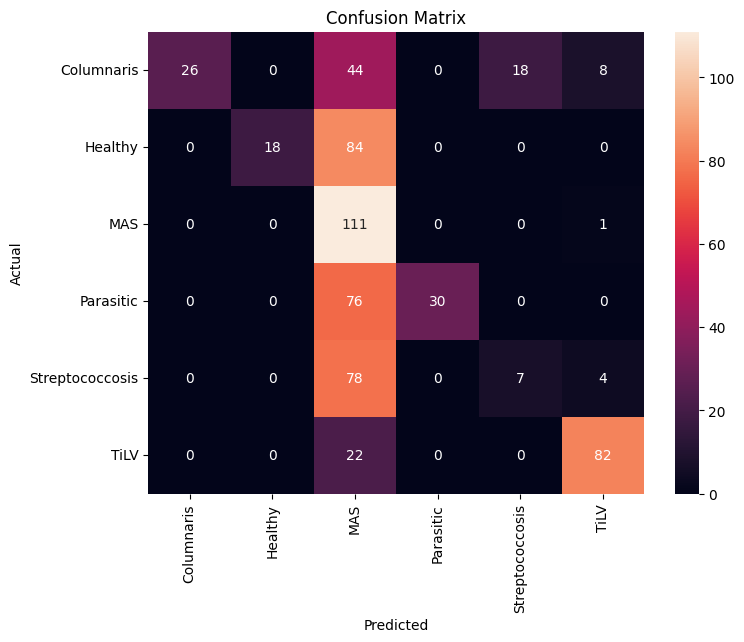

In [24]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)
plt.title(
    "Confusion Matrix"
)
plt.xlabel(
    "Predicted"
)
plt.ylabel(
    "Actual"
)
plt.show()

In [25]:
model.save(
    "tilapia_health_model.h5"
)
print(
    "Model saved successfully."
)

Model saved successfully.


Saving penyakit X.jpg to penyakit X.jpg


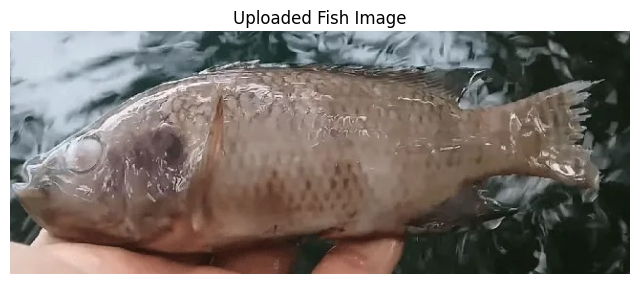

In [26]:
from google.colab import files
uploaded = files.upload()
img_path = list(
    uploaded.keys()
)[0]
img_display = load_img(
    img_path
)
plt.figure(figsize=(8,8))
plt.imshow(
    img_display
)
plt.axis("off")
plt.title(
    "Uploaded Fish Image"
)
plt.show()

In [27]:
img = load_img(
    img_path,
    target_size=(224,224)
)

img_array = img_to_array(
    img
)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(
    img_array
)

classes = list(
    train_generator.class_indices.keys()
)

predicted_index = np.argmax(
    prediction
)

predicted_class = classes[
    predicted_index
]

confidence = np.max(
    prediction
) * 100

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [28]:
for i, cls in enumerate(classes):
    prob = prediction[0][i] * 100
    print(
        f"{cls}: {prob:.2f}%"
    )

Columnaris: 0.00%
Healthy: 0.00%
MAS: 99.87%
Parasitic: 0.00%
Streptococcosis: 0.00%
TiLV: 0.13%


In [29]:
if predicted_class == "Healthy":
    status = "HEALTHY"
else:
    status = "DISEASED"

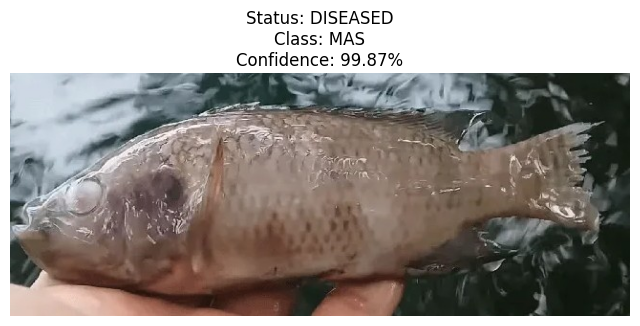

FISH HEALTH ANALYSIS RESULT
Predicted Class : MAS
Confidence Score: 99.87%
Health Status : DISEASED


In [30]:
plt.figure(figsize=(8,8))

plt.imshow(
    img_display
)

plt.axis("off")

plt.title(
    f"Status: {status}\n"
    f"Class: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.show()

print("="*60)

print("FISH HEALTH ANALYSIS RESULT")

print("="*60)

print(
    f"Predicted Class : {predicted_class}"
)

print(
    f"Confidence Score: {confidence:.2f}%"
)

print(
    f"Health Status : {status}"
)

print("="*60)